In [2]:
import pandas as pd


In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
data = {
    'Age': [25, 30, 35, 40, 45],
    'ownedHouse': ['No', 'Yes', 'Yes', 'No', 'Yes'],
    'creditScore': [600, 700, 750, 650, 800],
    'loanAmount': [10000, 20000, 30000, 15000, 35000],
    'Marital Status': ['Single', 'Married', 'Married', None, 'Divorced'],
    'Education': ['Bachelor', 'Master', 'PhD', 'Bachelor', 'Master'],
    'Employment Status': ['Full-time', 'Full-time', 'Self-employed', 'Part-time', 'Full-time'],
    'Loan Approval': ['No', 'Yes', 'Yes', 'No', 'Yes']
}

In [7]:
df = pd.DataFrame(data)
df.head(10)

,Age,ownedHouse,creditScore,loanAmount,Marital Status,Education,Employment Status,Loan Approval
0,25,No,600,10000,Single,Bachelor,Full-time,No
1,30,Yes,700,20000,Married,Master,Full-time,Yes
2,35,Yes,750,30000,Married,PhD,Self-employed,Yes
3,40,No,650,15000,NaN,Bachelor,Part-time,No
4,45,Yes,800,35000,Divorced,Master,Full-time,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                5 non-null      int64
 1   ownedHouse         5 non-null      str  
 2   creditScore        5 non-null      int64
 3   loanAmount         5 non-null      int64
 4   Marital Status     4 non-null      str  
 5   Education          5 non-null      str  
 6   Employment Status  5 non-null      str  
 7   Loan Approval      5 non-null      str  
dtypes: int64(3), str(5)
memory usage: 452.0 bytes


In [9]:
df.describe()

,Age,creditScore,loanAmount
count,5.000000,5.000000,5.000000
mean,35.000000,700.000000,22000.000000
std,7.905694,79.056942,10368.220677
min,25.000000,600.000000,10000.000000
25%,30.000000,650.000000,15000.000000
50%,35.000000,700.000000,20000.000000
75%,40.000000,750.000000,30000.000000
max,45.000000,800.000000,35000.000000


In [11]:
correlation_matrix = df[['Age', 'creditScore', 'loanAmount']].corr()
correlation_matrix

,Age,creditScore,loanAmount
Age,1.000000,0.700000,0.686244
creditScore,0.700000,1.000000,0.991241
loanAmount,0.686244,0.991241,1.000000


<Axes: >

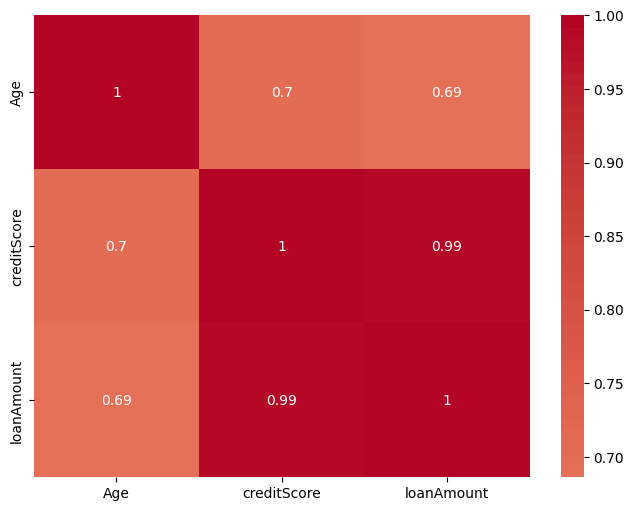

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

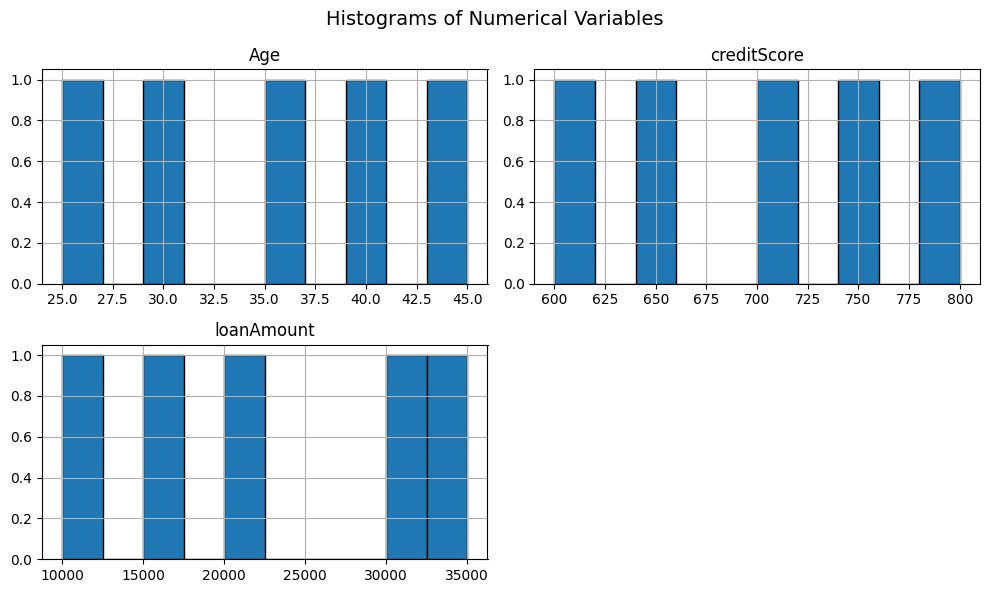

In [13]:
# 绘制所有数值变量的直方图
df.hist(figsize=(10,6), bins=10, edgecolor = 'black')
# 设置整个图形的大标题，字体大小为 14
plt.suptitle('Histograms of Numerical Variables', fontsize = 14)
# 自动调整子图参数，使之填充整个图像区域，防止标签重叠
plt.tight_layout()
# 显示最终生成的图像
plt.show()

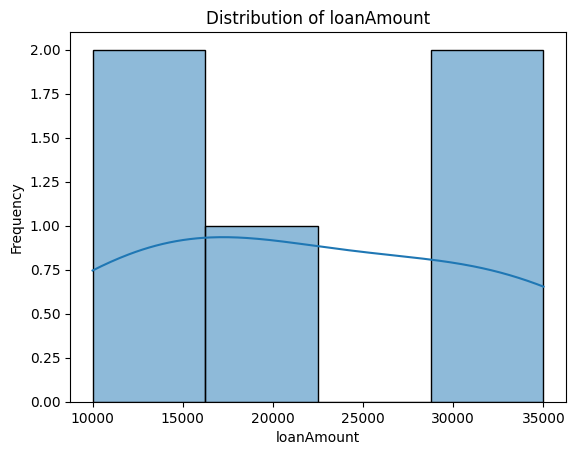

In [14]:
# histogram with kde with seaborn
sns.histplot(df['loanAmount'], kde=True)
plt.title('Distribution of loanAmount')
plt.xlabel('loanAmount')
plt.ylabel('Frequency')
plt.show()

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_text
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("data/IRIS.csv")
# Print first 5 rows
print(data.head(102))
# Fix olumn name issue
X = data.drop("species"
, axis=1) # Drop features only
y = data["species"] # Target column

     sepal_length  sepal_width  petal_length  petal_width          species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
2             4.7          3.2           1.3          0.2      Iris-setosa
3             4.6          3.1           1.5          0.2      Iris-setosa
4             5.0          3.6           1.4          0.2      Iris-setosa
..            ...          ...           ...          ...              ...
97            6.2          2.9           4.3          1.3  Iris-versicolor
98            5.1          2.5           3.0          1.1  Iris-versicolor
99            5.7          2.8           4.1          1.3  Iris-versicolor
100           6.3          3.3           6.0          2.5   Iris-virginica
101           5.8          2.7           5.1          1.9   Iris-virginica

[102 rows x 5 columns]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")


Accuracy: 1.00


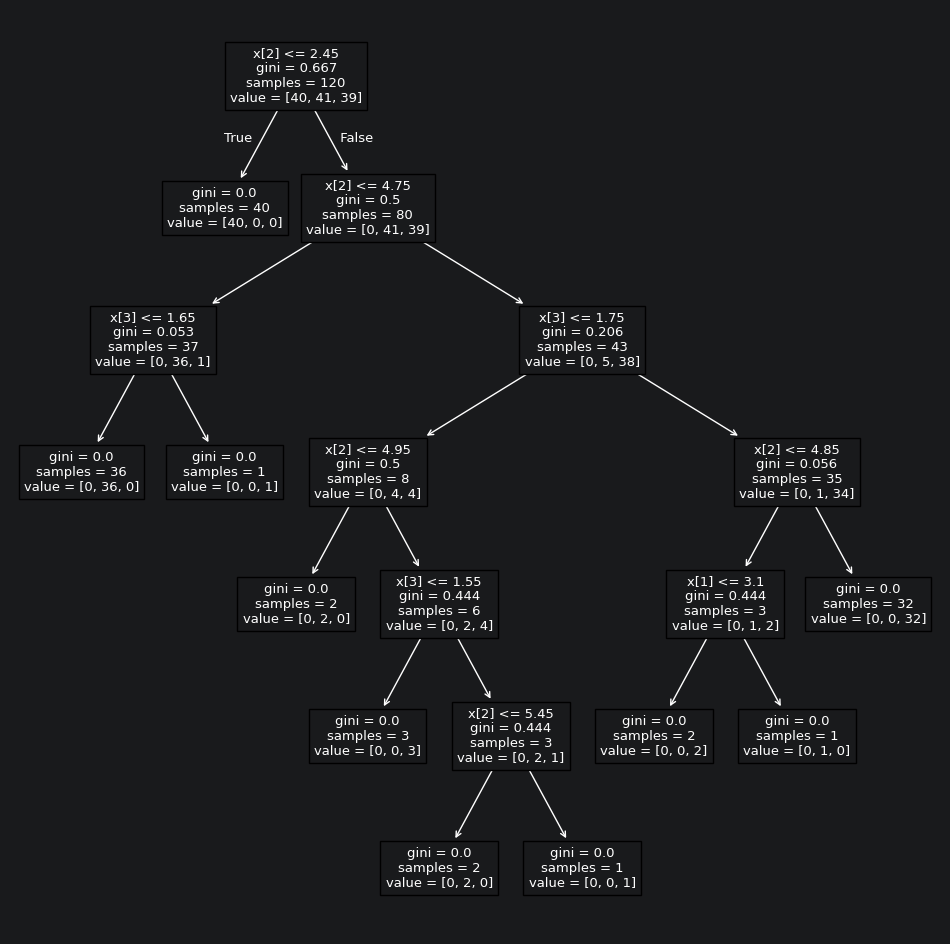

In [8]:
plt.figure(figsize=(12,12))
plot_tree(clf)
plt.show()